<a href="https://colab.research.google.com/github/muhammad-usman-tech/data-analysis-tasks/blob/main/MINI_PROJECTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

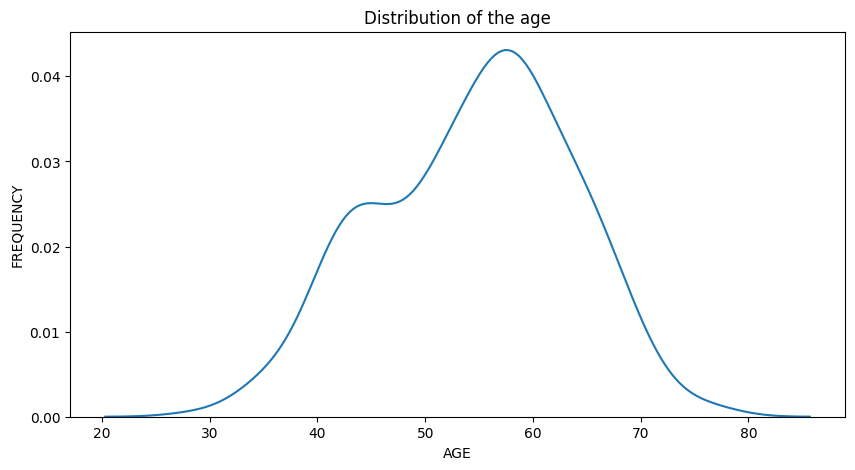

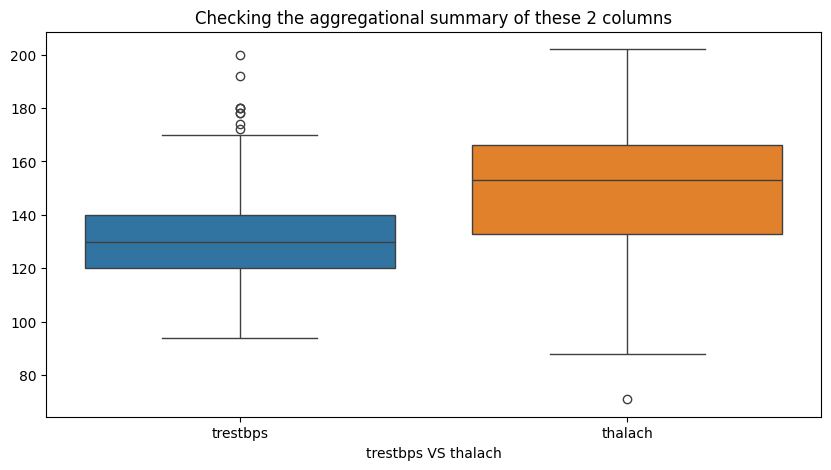

/tmp/ipykernel_2054/227926366.py:79: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data=df.groupby('IS_PATIENT')['IS_PATIENT'].count() #used this technique to find the count of the yes and no to show on the barplot


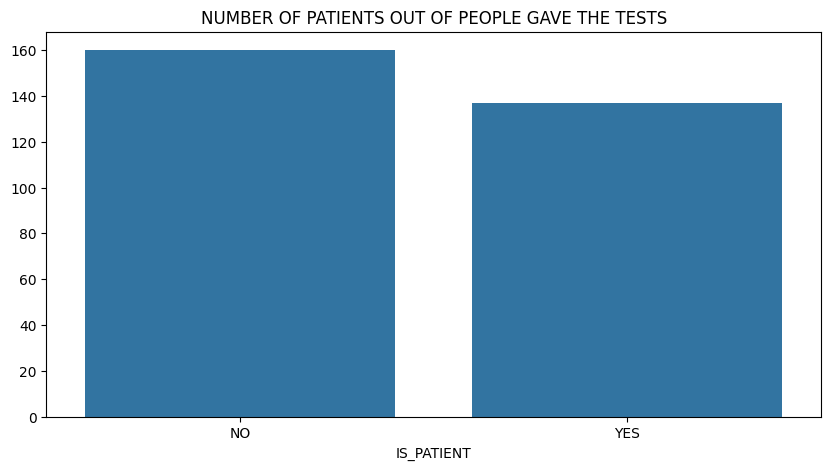

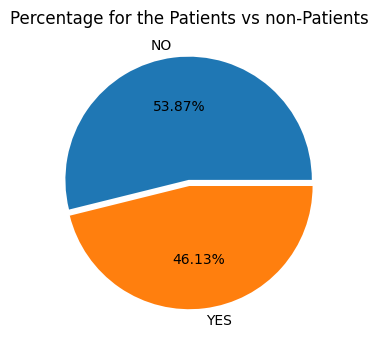

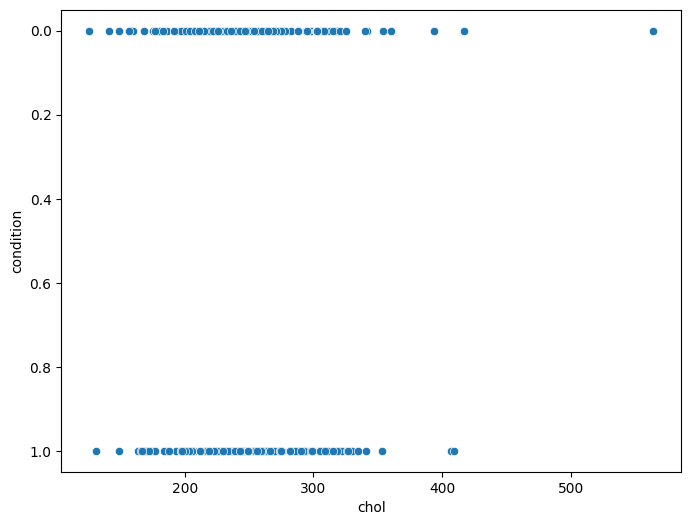

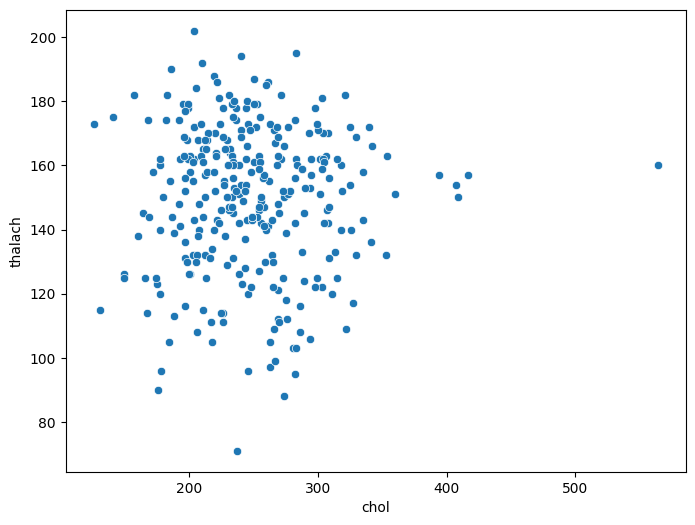

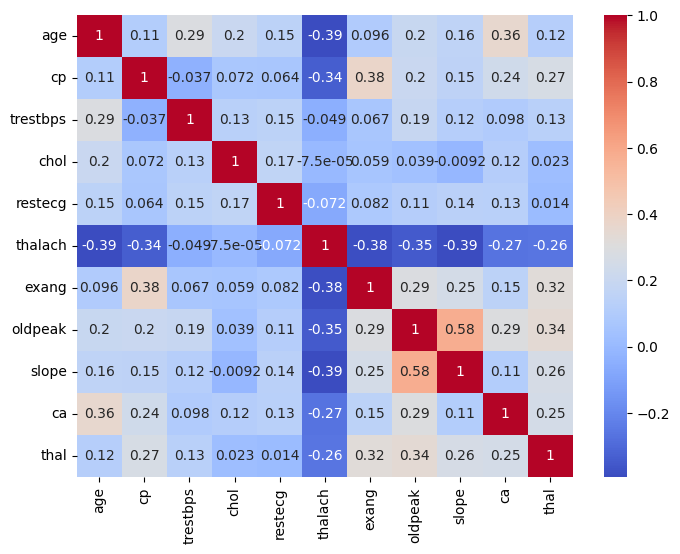

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   age         297 non-null    int64   
 1   sex         297 non-null    category
 2   cp          297 non-null    int64   
 3   trestbps    297 non-null    int64   
 4   chol        297 non-null    int64   
 5   fbs         297 non-null    object  
 6   restecg     297 non-null    int64   
 7   thalach     297 non-null    int64   
 8   exang       297 non-null    int64   
 9   oldpeak     297 non-null    float64 
 10  slope       297 non-null    int64   
 11  ca          297 non-null    int64   
 12  thal        297 non-null    int64   
 13  condition   297 non-null    category
 14  IS_PATIENT  297 non-null    category
dtypes: category(3), float64(1), int64(10), object(1)
memory usage: 29.2+ KB


/tmp/ipykernel_2054/227926366.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('IS_PATIENT')['IS_PATIENT'].count()
/tmp/ipykernel_2054/227926366.py:134: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['IS_PATIENT','sex'])['IS_PATIENT'].count()
/tmp/ipykernel_2054/227926366.py:147: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['IS_PATIENT','sex','chol_level'])['IS_PATIENT'].count()


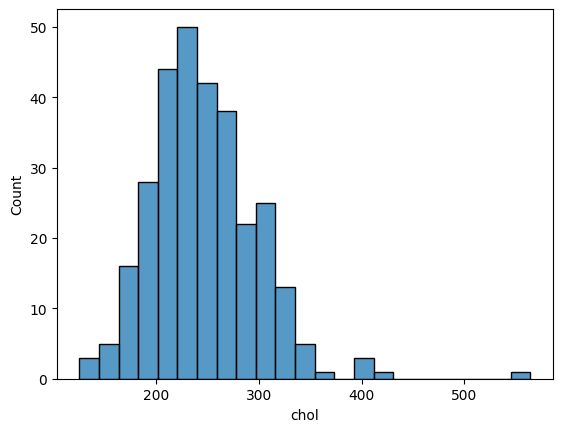

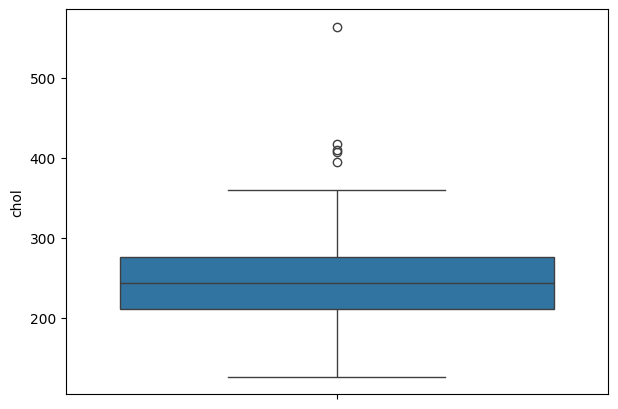

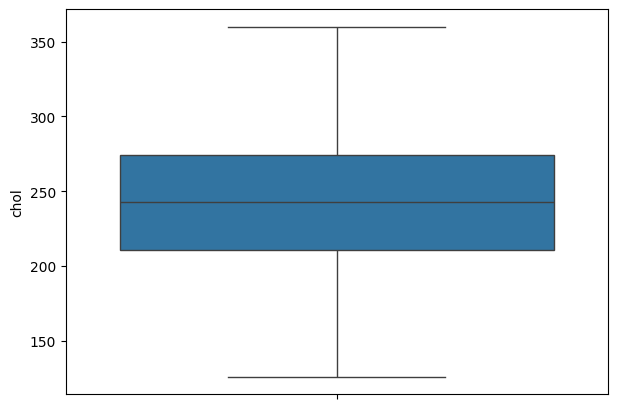

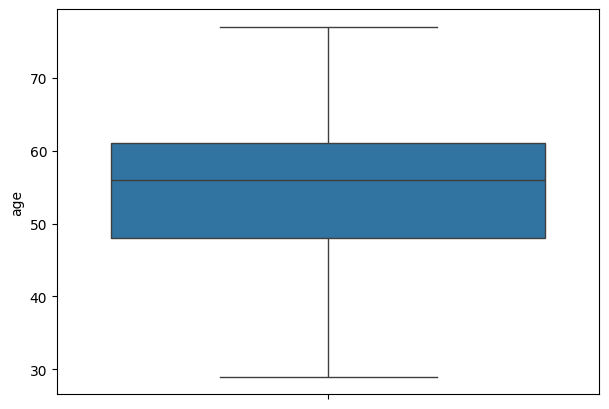

MAX age 77.0
MIN age 29.0


,count
fbs,
<=120 mg,254
>120mg,43


In [39]:
from numpy._core import numeric
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
# Step 1
df=pd.read_csv('/content/heart_cleveland_upload.csv')

# Step 2
df.shape
df.tail(5)

df.head(7)
df['thal'].unique()
df.describe()

# Step 3: have to do 3 things deal with the null values , duplicate values , correct the data type
# firstly dealing  the null data
null=df.isnull().sum()
# null there are 0 null values but still just find the percentage to tell or to revise the concepts by myself or checking if i remember the farmulaes
percentage=(null/len(df))*100
percentage
col_drop=percentage[percentage>=50]
df=df.drop(columns=col_drop)

# now filling (This part is not needed as there are no object columns and no nulls to fill)
# obj_columns=df.select_dtypes(include='object').columns
# df[obj_columns]=df[obj_columns].fillna(df[obj_columns].mode().iloc[0])
col_num=df.select_dtypes(include='number').columns
df[col_num]=df[col_num].fillna(df[col_num].mean())

# i have no categorical here right now so move next

# removing the duplicates

print('===============')
df.duplicated().sum() #got np.int64(0) duplicates
# but the code to remove the duplicate is the
# df=df.drop_duplicates()

# now correcting the data types and i am watching there are some columns that must be in the category not in the int
# so just converting main 2 attributes into the category(condition and the sex)
df['sex']=df['sex'].astype('category')
df['condition']=df['condition'].astype('category')

# df.info() #updated sucessfully but can also use the .replace function to convert in into the string and going to perform 1 column here
df['fbs'].unique() # got 0 and 1
df['fbs']=df['fbs'].replace({0:'<=120 mg',1:'>120mg'})

df.head()

# Step 4: uni variate so just taking the 2-3 graphs in the univariate maybe 2
# checking the distribution of the age
plt.figure(figsize=(10,5))
sns.kdeplot(df['age'])
plt.title('Distribution of the age')
plt.xlabel('AGE')
plt.ylabel('FREQUENCY')
plt.show()
# it was almost the bell curved means equally distributes no side was longer


# now checking the aggregational summary of the 2 columns using the box plot

plt.figure(figsize=(10,5))
sns.boxplot(data=df[['trestbps','thalach']])
plt.title('Checking the aggregational summary of these 2 columns')
plt.xlabel('trestbps VS thalach')
plt.show() #here the max of the trestbp is almost 170 and it contains almost sevral strange values after its max but thalach hax max of 200 and it doesnot contains any strange value

# Step 5: bi-variate charts
# prepairing for the box plot
df['IS_PATIENT']=df['condition'].apply(lambda x: 'YES' if x==1 else 'NO')


df['IS_PATIENT']
data=df.groupby('IS_PATIENT')['IS_PATIENT'].count() #used this technique to find the count of the yes and no to show on the barplot
plt.figure(figsize=(10,5))
sns.barplot(x=data.index,y=data.values)
plt.title('NUMBER OF PATIENTS OUT OF PEOPLE GAVE THE TESTS')
plt.show()
explode=[0.05,0]
# and also making the piechart of this data that will look good (i want to say the logic of data can be used for both piechart and the pie chart)
plt.figure(figsize=(6,4))
plt.pie(data,labels=data.index,autopct='%1.2f%%',explode=explode)
plt.title('Percentage for the Patients vs non-Patients')
plt.show()

# now making the scatter chart: is chol in blood is increasinf the patient rate
plt.figure(figsize=(8,6))
sns.scatterplot(x='chol',y='condition',data=df)
plt.show() #it gave a very down straight line may be the condition is categorical thats why no good results found
# now making it with the thalach to check the pattern
plt.figure(figsize=(8,6))
sns.scatterplot(x='chol',y='thalach',data=df)
plt.show() #here dots are spread allover the graph so no they are not connected to each other

# final making the heatmap or just leave the heat map for now

#Step6:  finding the coorelation

# df.info()
# df.head()

# these values count are the correltion for the objects or the categorical values or columns (tell me if i am right or not)
# for finding the corelation of the category we can yse the value count
df['IS_PATIENT'].value_counts()
df['fbs'].value_counts()

# now correlation for the whole data frame
# going to make the heat map

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

# thalac and slope got the strong negative relation and slope and oldpeak got the good positive relation



# STEP:7
# now using my own mind and trying to figure out the levels here for the data drilling in this heart dataset

df.info()
df.head()
# may be the first one will be by the total patients out of the results level-1-overall
# len(df) 297 total tests happen or record got of 297 people
df.groupby('IS_PATIENT')['IS_PATIENT'].count()
# out of 137 got the heart problem while the other 160 are the al ok

# level 2 segment wise (here by the sex)
df.groupby(['IS_PATIENT','sex'])['IS_PATIENT'].count()

# out of the 137 who got the problem there are only 25 female and all tye other are male

df.head()
sns.histplot(df['chol'])

# now by the chol level
df['chol_level']=pd.cut(df['chol'],
 bins=[0,200,300,400,500,700],
labels=['low','medium','high',"very high ","no chance to survive"])


df.groupby(['IS_PATIENT','sex','chol_level'])['IS_PATIENT'].count()
# female who are the patients have more cholestrol then the male person and one more interesting thing female who are not parient are having much higher chl in their blood means some times having chol in our bolld does not means that we can have the hert problem



# STEP 8: outliers and anomaly detection ok now it is going to be a some thing real i will make a box plot of some column and then see if there re outliers and then i will use the z-values method or IQr to see if that will change the box plot's noisy values or not

# like i am going to take the chol column it will be simple

# first making the boxplot
plt.figure(figsize=(7,5))
sns.boxplot(df['chol'])
plt.show()

# here boxplot is sohowing the maximum values is near 400 and also showing some outliers more then 400 and even after the 500
# now using the IQR method to remove these outliers
Q1=df['chol'].quantile(0.25)
Q3=df['chol'].quantile(0.75)
IQR=Q3-Q1

lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

median=df['chol'].median()

# we have two options here 1st is to take the data frame who has values less then and greaten the n these bounds thats simple and the next is to replance these with the median or the mean
df['chol']=np.where((df['chol']<lower_bound) | (df['chol']>upper_bound),median,df['chol'])

# now again creating the box plot to see the diference

plt.figure(figsize=(7,5))
sns.boxplot(df['chol'])
plt.show()
# box plot is outlier free
# now taking the age column and try to do it with the z-values
# first making the boxplot
plt.figure(figsize=(7,5))
sns.boxplot(df['age'])
plt.show() #age is almost clear so now just practice the z-values method

df['age_zscore']=np.abs(stats.zscore(df['age']))
df['age']=np.where(df['age_zscore']>3,df['age'].median(),df['age'])
df=df.drop(columns=['age_zscore'])

# STEP 9: finding trends and the use full info like frequeent values pattern
# unfortunately i did not get any date or time column so the trend finding by the time is't possible ut can find the frequent values pattern or any rare pattern by atleast 3-4 columns

# 1st
df['sex'].value_counts() #there were 201 male we should approach more females to give the test or to participat in these medical activities

print('=============')
print('MAX age', df['age'].max())
print('MIN age', df['age'].min())
# max is 77 and the min is 29
print('=============')
df.head()

df['fbs'].value_counts()
#254 people have less then equal to 120 mg  only i guess 54 people had greater then 120 thats good or not i dont know.
# STEP 10:
# INTERPRETATION:
# Okay, so this heart Cleveland report.csv dataset contains 297 tests and 16 attributes, like 16 are the properties regarding that tests. Against 297 tests, we got 16 properties. We got a lot of things, like if a patient has cholesterol, like fasting blood sugar, sleeping sugar, sleeping cholesterol, like a lot of things, okay? So if we will start from the correlation, so we got the correlation in basically two things, and that was the most important, and I would say, yeah. Okay, so the correlation was the THALACH and slope. Got the strong negative relation, and the slope and old peak got the good positive relation, and that was the correlation from the numeric values. And I have also did the correlation of categories you can in the previous code. And if I will talk about the data drilling, so, like, out of 297, 137 got the heart problem, while the other 160 are all okay. And if I go more and check regarding the gender, so out of 137, there were 25 females only. Like females got less tests. Then if we will talk about the cholesterol level, then the people... cholesterol level was not really mattering, because I have seen the people who don't get the heart problem, they also have in the females. They also got the very severe, like no chance to survive cholesterol level. That was so severe. So it doesn't matter if you have a cholesterol and you are a heart patient or not, okay? That was the three-level data drilling. And after that we come to the outlier finding. So yeah, we find the outlier from the CHOL cholesterol, and in the cholesterol, it is obvious to find the cholesterol outliers in the box plot because cholesterol can be someone have very high, like maybe more than 650, and someone maybe, or 700, and someone can have like only 200. So that was completely normal. But I found the outliers, okay? And then in the age outliers, there was nothing. The age column was perfect regarding the outliers. Like using the box plot, I found no outlier. And in the trend finding, like from the step nine, which will be step nine, so the basic thing is 1,204 male got the test, and only few females just give the test. So I think we should approach more females to give the test or participate in the medical activities. And we got the maximum age of 77, which is a good thing if people of 77 ages coming, but only the minimum age is 29. So that's a normal thing. Maybe people before the 29 age, they don't feel anything to participate or give the test or participate in any kind of medical activity or medical test, even is it free or not. Then we find the FBS. FBS is resting or fasting blood sugar. So when you are fasting or when you are not having a very heavy diet, so these people, like 254 people, got the less, like 120 milligrams. Like it's a good thing if our blood sugar is low while fasting or not eating at the heavy time, or, like, eating all the time. That was all the trends. And the things to find or to, you can say, like, what if we have to investigate, we can investigate the cholesterol level. Like the woman, she didn't give test— sorry, there was a female who was not a heart patient, but her cholesterol level was much high, like more than 500. But she was not a heart patient. Maybe she can be some other patient, so that must be investigated. And if I will talk about you in the template, you ask me what should be done based on the finding. I think I have found three to four useful things about the cholesterol level. Then the males, most of the males got the test, and most of the males were the patients. Only few females were the patients. And some of the things like slope and old peak are, like, have a positive correlation, and some, like THALACH and slope sometimes have a negative correlation. It was also a finding, and there are a lot of things like slope and other things. It was all the three to four many findings I have found. I think it's a long time I am working since six months, and it is all I can found by doing these steps. Sometimes I feel very down, but it's okay.